In [45]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.feature_selection import chi2

# For better plot style
plt.style.use('ggplot')

In [46]:
# 2) Load Dataset

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

df = X.copy()
df["target"] = y

print("Dataset Loaded Successfully ")
print()

Dataset Loaded Successfully 



In [47]:
# 3) EDA

print("Shape of Dataset:", df.shape)

Shape of Dataset: (178, 14)


In [48]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  targe

In [49]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    flo

In [50]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572

In [51]:
print("\nClass Distribution:")
print(df["target"].value_counts())


Class Distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


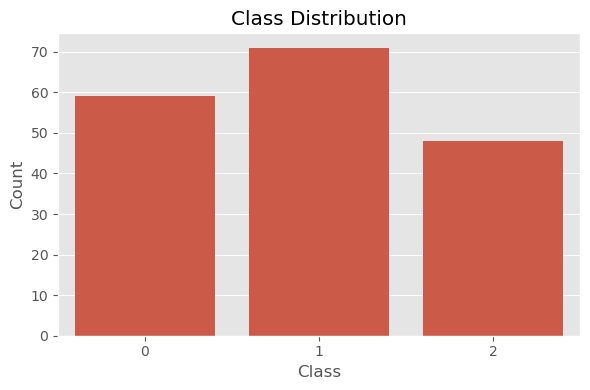

In [52]:
# Plot Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [53]:
# 4) Data Cleaning Checks

print("\nMissing Values Check:")
print(df.isnull().sum())


Missing Values Check:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [54]:
print("\nDuplicate Rows Check:")
print("Number of duplicates:", df.duplicated().sum())


Duplicate Rows Check:
Number of duplicates: 0


In [55]:
print("\nConclusion:")
print(" Dataset contains NO missing values.")
print(" Dataset contains NO duplicate rows.")


Conclusion:
 Dataset contains NO missing values.
 Dataset contains NO duplicate rows.


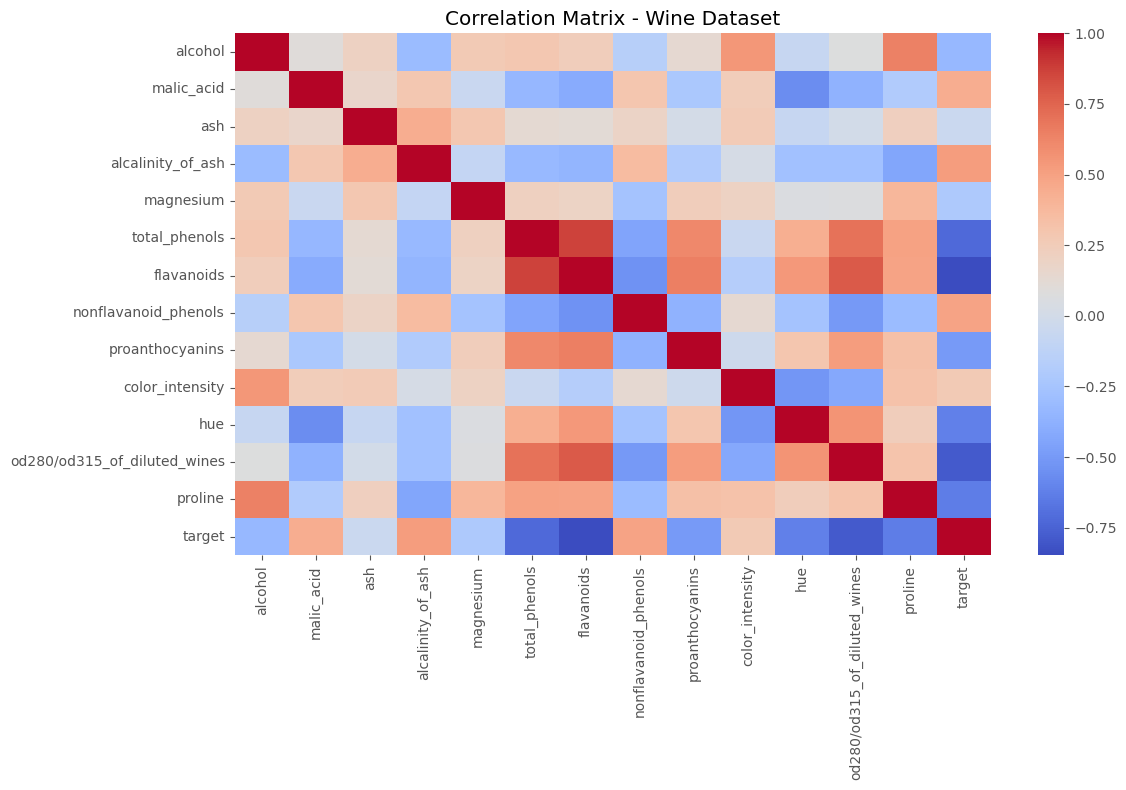

In [56]:
# 5) Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix - Wine Dataset")
plt.tight_layout()
plt.show()

In [57]:
# 6) Pearson Correlation Ranking

pearson_scores = {}

for col in X.columns:
    correlation = X[col].corr(y)  
    pearson_scores[col] = abs(correlation)

pearson_ranking = (
    pd.Series(pearson_scores)
    .sort_values(ascending=False)
)

print("\nPearson Feature Ranking:")
display(pearson_ranking)


Pearson Feature Ranking:


flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
dtype: float64

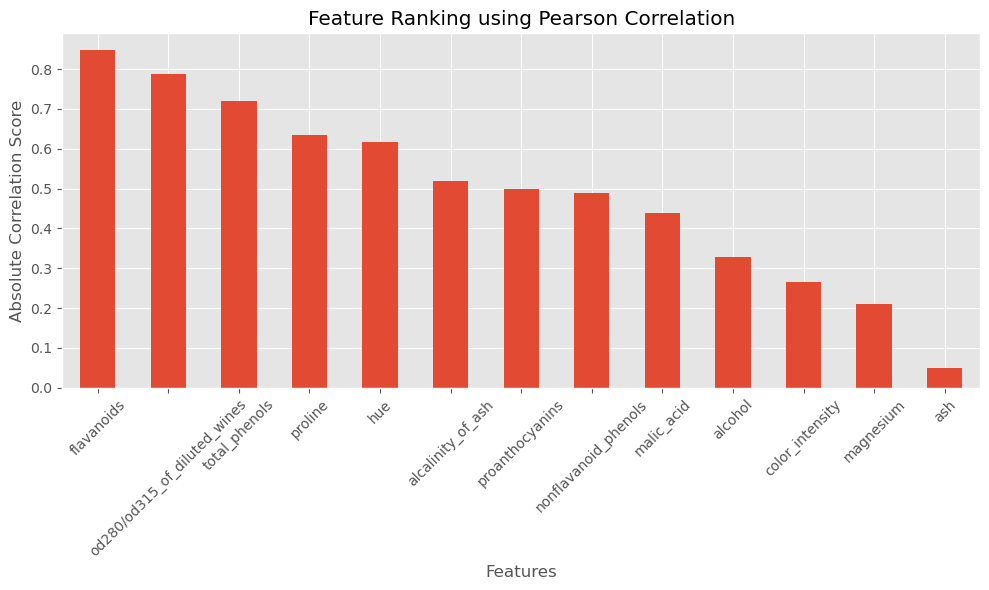

In [58]:
# Plot Pearson Ranking
plt.figure(figsize=(10, 6))
pearson_ranking.plot(kind='bar')
plt.title("Feature Ranking using Pearson Correlation")
plt.ylabel("Absolute Correlation Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [59]:
# 7) Chi-Square Ranking

chi_scores, p_values = chi2(X, y)

chi_ranking = (
    pd.Series(chi_scores, index=X.columns)
    .sort_values(ascending=False)
)

print("\nChi-Square Ranking:")
display(chi_ranking)



Chi-Square Ranking:


proline                         16540.067145
color_intensity                   109.016647
flavanoids                         63.334308
magnesium                          45.026381
alcalinity_of_ash                  29.383695
malic_acid                         28.068605
od280/od315_of_diluted_wines       23.389883
total_phenols                      15.623076
proanthocyanins                     9.368283
alcohol                             5.445499
hue                                 5.182540
nonflavanoid_phenols                1.815485
ash                                 0.743381
dtype: float64

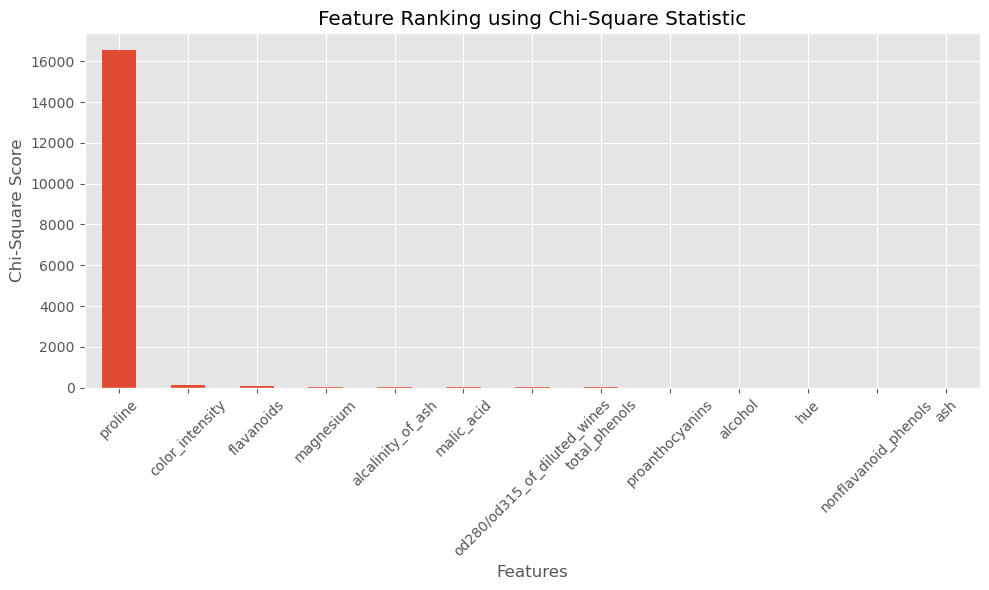

In [60]:
# Plot Chi-Square Ranking
plt.figure(figsize=(10, 6))
chi_ranking.plot(kind='bar')
plt.title("Feature Ranking using Chi-Square Statistic")
plt.ylabel("Chi-Square Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [61]:
# 8) Comparison Table

comparison_df = pd.DataFrame({
    "Pearson Score": pearson_ranking,
    "Chi-Square Score": chi_ranking
})

print("\nComparison Table:")
display(comparison_df)


Comparison Table:


,Pearson Score,Chi-Square Score
alcalinity_of_ash,0.517859,29.383695
alcohol,0.328222,5.445499
ash,0.049643,0.743381
color_intensity,0.265668,109.016647
flavanoids,0.847498,63.334308
hue,0.617369,5.182540
magnesium,0.209179,45.026381
malic_acid,0.437776,28.068605
nonflavanoid_phenols,0.489109,1.815485
od280/od315_of_diluted_wines,0.788230,23.389883


In [62]:

# 9) Top-K Feature Example

# This section prepares top-k features
# for use in (LDA training)

k = 5

top_k_pearson = pearson_ranking.head(k)
top_k_chi = chi_ranking.head(k)

print(f"\nTop {k} Features based on Pearson:")
display(top_k_pearson)

print(f"\nTop {k} Features based on Chi-Square:")
display(top_k_chi)



Top 5 Features based on Pearson:


flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
dtype: float64


Top 5 Features based on Chi-Square:


proline              16540.067145
color_intensity        109.016647
flavanoids              63.334308
magnesium               45.026381
alcalinity_of_ash       29.383695
dtype: float64

In [63]:
# 10) Save Rankings 
comparison_df.to_csv("feature_ranking.csv")
